# Day 18 of ML 30-Days Challenge

# Task

**Support Vector Machine (SVM)**: Understand the concepts of hyperplanes and margins. Explore the use of different kernels (like linear and RBF) and the "kernel trick," which allows SVMs to efficiently handle non-linear decision boundaries.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

###1. Create a 200-row synthetic dataset (binary classification, slightly non-linear separability)

In [66]:
X, y = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=0.8, flip_y=0.05, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42, stratify=y )

In [67]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    acc_tr = accuracy_score(y_tr, y_pred_tr)
    acc_te = accuracy_score(y_te, y_pred_te)

    print(f"\n{name}")
    print("-"*len(name))
    print(f"Train acc: {acc_tr:.3f} | Test acc: {acc_te:.3f}")
    print(classification_report(y_te, model.predict(X_te), digits=3))

    return y_pred_te, acc_te

###2. Implementing a Scaled Linear SVM

In [68]:
linear_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", random_state=42))
])
linear_clf.fit(X_train, y_train)
y_pred_linear, acc_linear = evaluate_model("Linear SVM", linear_clf, X_train, y_train, X_test, y_test)


Linear SVM
----------
Train acc: 0.771 | Test acc: 0.767
              precision    recall  f1-score   support

           0      0.742     0.793     0.767        29
           1      0.793     0.742     0.767        31

    accuracy                          0.767        60
   macro avg      0.768     0.768     0.767        60
weighted avg      0.768     0.767     0.767        60



###3) Implementing a Scaled RBF SVM (Untunned)

In [69]:
rbf_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", random_state=42))
])
rbf_clf.fit(X_train, y_train)
y_pred_rbf_basic, acc_rbf_basic = evaluate_model("RBF SVM (untuned)", rbf_clf, X_train, y_train, X_test, y_test)


RBF SVM (untuned)
-----------------
Train acc: 0.793 | Test acc: 0.800
              precision    recall  f1-score   support

           0      0.758     0.862     0.806        29
           1      0.852     0.742     0.793        31

    accuracy                          0.800        60
   macro avg      0.805     0.802     0.800        60
weighted avg      0.806     0.800     0.800        60



###4. Tuning SVM Hyperparameters (C and gamma) for RBF

In [70]:
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", "auto", 0.1, 0.01, 0.001]
}
grid = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", random_state=42))
    ]),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_rbf = grid.best_estimator_
print("\nBest RBF params:", grid.best_params_)
y_pred_best, acc_best = evaluate_model("RBF SVM (tuned)", best_rbf, X_train, y_train, X_test, y_test)


Best RBF params: {'svc__C': 100, 'svc__gamma': 0.01}

RBF SVM (tuned)
---------------
Train acc: 0.800 | Test acc: 0.833
              precision    recall  f1-score   support

           0      0.806     0.862     0.833        29
           1      0.862     0.806     0.833        31

    accuracy                          0.833        60
   macro avg      0.834     0.834     0.833        60
weighted avg      0.835     0.833     0.833        60



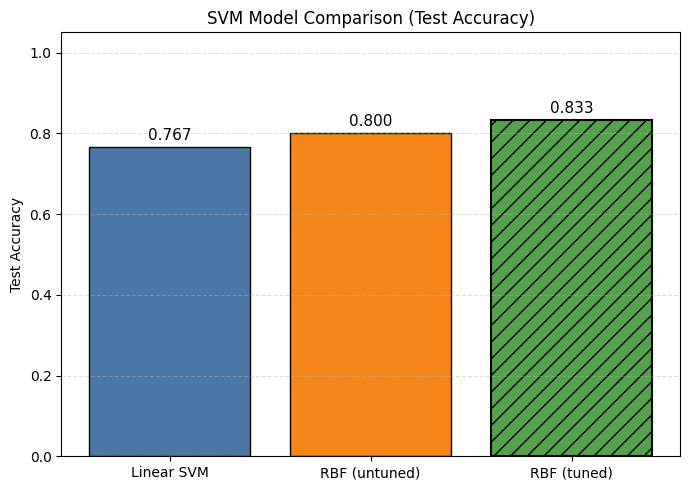

In [71]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Linear SVM", "RBF (untuned)", "RBF (tuned)"]
accuracies = [acc_linear, acc_rbf_basic, acc_best]

plt.figure(figsize=(7,5))
bars = plt.bar(labels, accuracies, color=["#4C78A8", "#F58518", "#54A24B"], edgecolor="black")

for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 0.01, f"{h:.3f}",
             ha="center", va="bottom", fontsize=11)

best_idx = int(np.argmax(accuracies))
bars[best_idx].set_hatch("//")
bars[best_idx].set_linewidth(1.5)

plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")
plt.title("SVM Model Comparison (Test Accuracy)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()